# Teste Interativo da Classe `FlightEDA`

Este notebook serve para validar e testar individualmente cada uma das etapas do pipeline da classe `FlightEDA` definida em `notebooks/eda.py`.

In [1]:
import sys
from pathlib import Path

# Adiciona o diretório raiz do projeto para permitir importar a classe do módulo notebooks.eda
sys.path.append(str(Path(".").resolve().parent))

from notebooks.eda import FlightEDA

In [2]:
# Inicializa o objeto EDA especificando os caminhos corretos relativos ao diretório notebooks/
eda = FlightEDA(
    input_path="../data/raw/flights.csv",
    output_path="../data/processed/flights_model.parquet"
)

In [3]:
# 1. Testar o carregamento dos dados brutos
df = eda.load_data()
print(f"Total de linhas carregadas: {df.height}")

Carregando dados de: ../data/raw/flights.csv ...
Total de linhas carregadas: 5819079


In [4]:
# 2. Testar exibição de informações básicas (schema, nulos, etc.)
eda.print_basic_info()


=== Informações Básicas ===
Shape: (5819079, 31)

Head:
shape: (5, 31)
┌──────┬───────┬─────┬─────────────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ YEAR ┆ MONTH ┆ DAY ┆ DAY_OF_WEEK ┆ … ┆ SECURITY_DEL ┆ AIRLINE_DELA ┆ LATE_AIRCRAF ┆ WEATHER_DELA │
│ ---  ┆ ---   ┆ --- ┆ ---         ┆   ┆ AY           ┆ Y            ┆ T_DELAY      ┆ Y            │
│ i64  ┆ i64   ┆ i64 ┆ i64         ┆   ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│      ┆       ┆     ┆             ┆   ┆ i64          ┆ i64          ┆ i64          ┆ i64          │
╞══════╪═══════╪═════╪═════════════╪═══╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 2015 ┆ 1     ┆ 1   ┆ 4           ┆ … ┆ null         ┆ null         ┆ null         ┆ null         │
│ 2015 ┆ 1     ┆ 1   ┆ 4           ┆ … ┆ null         ┆ null         ┆ null         ┆ null         │
│ 2015 ┆ 1     ┆ 1   ┆ 4           ┆ … ┆ null         ┆ null         ┆ null         ┆ null         │
│ 2015 ┆ 1     ┆ 1 

In [5]:
# 3. Testar o pré-processamento do target e filtragem de cancelados/desviados
df_model = eda.preprocess_and_filter()


=== Pré-processamento e Filtragem ===
Amostra do Target (ARRIVAL_DELAY vs is_delayed):
shape: (5, 2)
┌───────────────┬────────────┐
│ ARRIVAL_DELAY ┆ is_delayed │
│ ---           ┆ ---        │
│ i64           ┆ i8         │
╞═══════════════╪════════════╡
│ -22           ┆ 0          │
│ -9            ┆ 0          │
│ 5             ┆ 1          │
│ -9            ┆ 0          │
│ -21           ┆ 0          │
└───────────────┴────────────┘

Distribuição do target (is_delayed):
shape: (3, 3)
┌────────────┬─────────┬───────────┐
│ is_delayed ┆ len     ┆ pct       │
│ ---        ┆ ---     ┆ ---       │
│ i8         ┆ u32     ┆ f64       │
╞════════════╪═════════╪═══════════╡
│ null       ┆ 105071  ┆ 1.805629  │
│ 1          ┆ 2086896 ┆ 35.862995 │
│ 0          ┆ 3627112 ┆ 62.331376 │
└────────────┴─────────┴───────────┘
Shape após filtrar cancelados e desviados: (5714008, 32)

Estatísticas médias de atraso:
shape: (1, 4)
┌──────────────────────┬────────────────────────┬────────────────────

In [6]:
# 4. Testar as agregações e sumarizações das taxas de atraso
eda.run_aggregations()


=== Executando Agregações ===

Top 10 Companhias com maior taxa de atraso:
shape: (10, 5)
┌─────────┬──────────┬─────────────────────┬───────────────────────┬─────────────┐
│ AIRLINE ┆ qtd_voos ┆ media_arrival_delay ┆ media_departure_delay ┆ taxa_atraso │
│ ---     ┆ ---      ┆ ---                 ┆ ---                   ┆ ---         │
│ str     ┆ u32      ┆ f64                 ┆ f64                   ┆ f64         │
╞═════════╪══════════╪═════════════════════╪═══════════════════════╪═════════════╡
│ NK      ┆ 115193   ┆ 14.4718             ┆ 15.883101             ┆ 0.493841    │
│ F9      ┆ 90090    ┆ 12.504706           ┆ 13.303352             ┆ 0.457676    │
│ HA      ┆ 76041    ┆ 2.023093            ┆ 0.469918              ┆ 0.396878    │
│ VX      ┆ 61248    ┆ 4.737706            ┆ 8.993486              ┆ 0.394788    │
│ US      ┆ 194223   ┆ 3.706209            ┆ 6.081                 ┆ 0.39277     │
│ B6      ┆ 262042   ┆ 6.677861            ┆ 11.442467             ┆ 0.389243  


Gerando Gráficos...


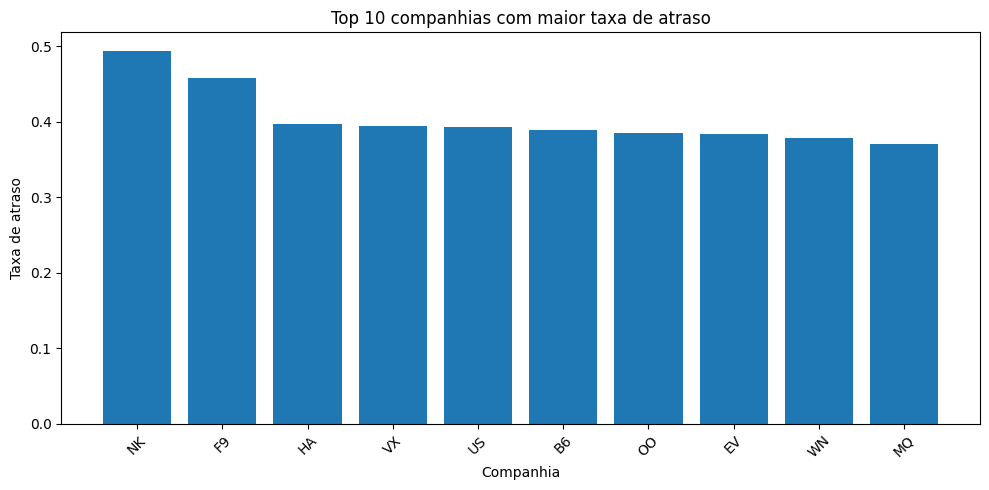

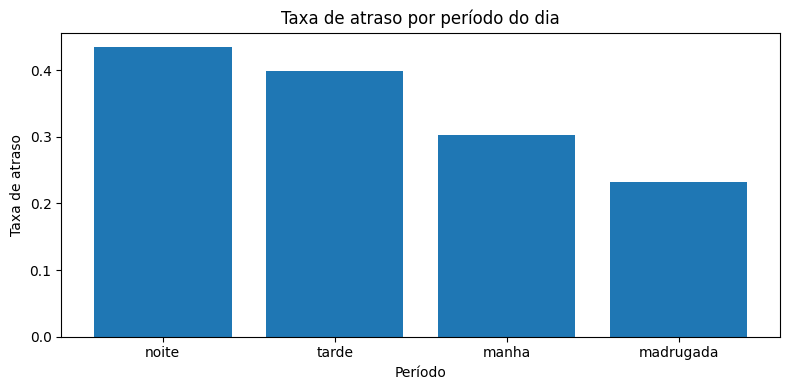

Voos no período da noite apresentam maior taxa de atraso, possivelmente devido ao acúmulo de atrasos ao longo do dia.


In [7]:
# 5. Testar a geração de gráficos
eda.plot_charts()

In [8]:
# 6. Testar o salvamento em arquivo parquet
eda.save_processed_data()


Salvando dados processados em parquet...
Arquivo salvo com sucesso em: ../data/processed/flights_model.parquet


In [9]:
# 7. Testar a exibição da discussão de valores ausentes
eda.show_nulls_discussion()


=== Análise de Valores Ausentes ===
1. ARRIVAL_DELAY:
   - Valores nulos associados a voos cancelados ou desviados
   - Estratégia: remoção desses registros para viabilizar a modelagem

2. Variáveis de delay (AIRLINE_DELAY, WEATHER_DELAY, etc.):
   - Alto volume de valores nulos (~80% dos dados)
   - Interpretação: ausência de atraso daquela causa
   - Estratégia:
       - Para EDA: preenchimento com 0
       - Para modelagem: remoção para evitar data leakage

3. Variáveis categóricas:
   - Baixa incidência de valores ausentes
   - Estratégia: imputação pela moda (pipeline de modelagem)

4. Variáveis numéricas:
   - Baixa incidência de valores ausentes
   - Estratégia: imputação pela mediana (pipeline de modelagem)

Null counts após demonstração de preenchimento:
shape: (32, 2)
┌─────────────────────┬──────────┐
│ column              ┆ column_0 │
│ ---                 ┆ ---      │
│ str                 ┆ u32      │
╞═════════════════════╪══════════╡
│ YEAR                ┆ 0        │
